# Case: SVC field uncertainty budget — real pipeline code

**Authors:** L. Mihai (laura.mihai@inflpr.ro)

**Reference:** Werfeli, Mihai et al. (2026), *"Uncertainty propagation and
intercomparison of multi-sensor measurements of vegetation stress in
sub-optimal conditions."*

Same real pipeline code as
[`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb)
(originally written by Mike Werfeli), applied to the **SVC HR-1024i**
instrument instead of the ASD FieldSpec 4. The white-panel-ratio formula,
the cloud-uncertainty estimation, and the `punpy` covariance-based
combination are identical between the two instruments — the only real
difference is how the SVC's raw export is read: its native wavelength grid
is **not** a uniform 1nm spacing (unlike the ASD), so it is interpolated
onto one (350-2500nm, 1nm steps) before anything else happens, exactly as
the original script does.

Runs end to end on the same real example: Plot 103 of the 2025 Norway
campaign (with Plot 105 as the trailing white-reference pair).

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline, PchipInterpolator
import punpy
import comet_maths as ctm
import matplotlib.pyplot as plt

DATA_DIR = "../data/case-asd-svc-plot103"
RAW_PATH = f"{DATA_DIR}/raw_SVC_plot103_105.csv"
PANEL_AM_PATH = f"{DATA_DIR}/panel_certificate_WP1_AM.csv"
PANEL_LM_PATH = f"{DATA_DIR}/panel_certificate_WP2_LM.csv"
U_PANEL_AM_PATH = f"{DATA_DIR}/panel_uncertainty_WP1_AM.csv"
U_PANEL_LM_PATH = f"{DATA_DIR}/panel_uncertainty_WP2_LM.csv"

realisations_n = int(1e4)

## 1. Reading the raw field file — with the extra SVC grid step

Same three groups of rows as the ASD case (`fsfwr` = WP1/AM panel scans,
`laurawr` = WP2/LM panel scans, everything else = target scans), but the
SVC's raw wavelength columns are **not** evenly spaced. Each row is
individually cubic-spline-interpolated onto a uniform 1nm grid
(350-2500nm) before anything downstream happens — otherwise the plot
positions and the panel scans wouldn't line up wavelength-by-wavelength.

In [2]:
def time_to_seconds(t):
    if type(t) == np.ndarray:
        return [i.hour * 3600 + i.minute * 60 + i.second for i in t]
    elif type(t) != list:
        return t.hour * 3600 + t.minute * 60 + t.second


def read_Field_day_csv_svc(path, plot_no):
    df = pd.read_csv(path, low_memory=False)
    wvl_idx, plot_idx = 16, 8  # SVC export has a different column layout than the ASD one

    L_data = df.iloc[:, wvl_idx:]
    wvls_native = L_data.columns.astype(float).tolist()

    # Interpolate every row from its native (non-uniform) grid onto a uniform 1nm grid
    wvls_uniform = np.arange(350, 2501)

    def interp_row(row):
        wvls_sorted = sorted([float(w) for w in row.index])
        cs = CubicSpline(wvls_sorted, list(row))
        return cs(wvls_uniform)

    wvls_arr = np.asarray(wvls_native)
    idx = np.where((wvls_arr >= wvls_uniform[0]) & (wvls_arr <= wvls_uniform[-1]))[0]
    L_data = L_data.iloc[:, idx]
    L_data = L_data.apply(interp_row, axis=1)
    L_data = pd.DataFrame(L_data.tolist(), index=L_data.index, columns=wvls_uniform)

    plot_data_dict, WR_LM_dict, WR_AM_dict = {}, {}, {}
    plot_names = np.asarray(df.iloc[:, plot_idx].tolist())
    t_stamps = pd.to_datetime(df['Acquisition Time']).dt.time.to_numpy()

    for pid in plot_no:
        positions_fsf = np.asarray([i for i, s in enumerate(plot_names) if "fsfwr" in s and pid in s])
        positions_laura = np.asarray([i for i, s in enumerate(plot_names) if "laurawr" in s and pid in s])
        WR_AM_dict[pid] = (np.asarray(L_data.iloc[positions_fsf, :]), np.asarray(t_stamps[positions_fsf]))
        WR_LM_dict[pid] = (np.asarray(L_data.iloc[positions_laura, :]), np.asarray(t_stamps[positions_laura]))
        position_plot = np.asarray([i for i, s in enumerate(plot_names) if pid in s])
        mask = ~np.isin(position_plot, np.concatenate([positions_fsf, positions_laura]))
        position_plot = position_plot[mask]
        plot_data_dict[pid] = (np.asarray(L_data.iloc[position_plot, :]), np.asarray(t_stamps[position_plot]))

    return plot_data_dict, WR_LM_dict, WR_AM_dict, list(wvls_uniform)


plot_no = ['103', '105']
L, WR_LM, WR_AM, wvls = read_Field_day_csv_svc(RAW_PATH, plot_no)
print(f"{len(L['103'][0])} target scans for plot 103 (SVC has 4 positions x 5 scans = 20, vs. ASD's 5x5 = 25)")
print(f"{len(WR_AM['103'][0])} WP1/AM panel scans, {len(WR_LM['103'][0])} WP2/LM panel scans")

20 target scans for plot 103 (SVC has 4 positions x 5 scans = 20, vs. ASD's 5x5 = 25)
5 WP1/AM panel scans, 5 WP2/LM panel scans


## 2. Panel calibration certificates

Identical panel certificates to the ASD case — the same two physical white
reference panels (WP1/AM and WP2/LM) were used for both instruments in the
campaign.

In [3]:
def rho_panel_interp(file_path, wvls, wvls_range=(350, 2500)):
    wvls = np.asarray(wvls)
    if 'WP1_AM' in file_path:
        df = pd.read_csv(file_path)
        wvls_rho = np.asanyarray(df['lambda'])
        idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
        col = 'sigma (k=2)' if 'uncertainty' in file_path else 'rho'
        rho_interp = np.asarray(df[col][idx])
        wvls_rho = wvls_rho[idx]
        cs = PchipInterpolator(wvls_rho, rho_interp) if 'uncertainty' in file_path else CubicSpline(wvls_rho, rho_interp)
        wvls_new = np.arange(wvls_range[0], wvls_range[1] + 1)
        return cs(wvls_new)
    elif 'WP2_LM' in file_path:
        df = pd.read_csv(file_path)
        if 'uncertainty' in file_path:
            wvls_rho = np.asarray(df.iloc[:, 0])
            idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
            u_raw = np.asarray(df.iloc[idx, 1])
            cs = PchipInterpolator(wvls_rho[idx], u_raw)
            return cs(np.arange(wvls_range[0], wvls_range[1] + 1))
        wvls_rho = np.asarray(df.iloc[:, 0])
        idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
        rho_raw = np.asarray(df.iloc[idx, 1])
        rho_raw_dec = np.asarray(df.iloc[idx, 2])
        num_digits = np.floor(np.log10(rho_raw_dec) + 1).astype(int)
        rho_raw = (rho_raw + rho_raw_dec / (10 ** num_digits)) / 100
        rho = np.ones(len(wvls))
        wvls_rho2 = wvls_rho[idx]
        cs = CubicSpline(wvls_rho2, rho_raw)
        wvls_ip = np.arange(wvls_range[0], wvls_rho[max(idx)])
        rho_interp = cs(wvls_ip)
        rho[:len(rho_raw) - 1] *= rho_interp
        ones_idx = np.where(rho == 1)
        if len(ones_idx[0]) > 0:
            rho[ones_idx] *= rho_interp[ones_idx[0][0] - 1]
        return rho


rho_interp_AM = rho_panel_interp(PANEL_AM_PATH, wvls)
rho_interp_LM = rho_panel_interp(PANEL_LM_PATH, wvls)
u_rho_am_abs = rho_interp_AM * (rho_panel_interp(U_PANEL_AM_PATH, wvls) / 2)
u_rho_lm_abs = rho_interp_LM * (rho_panel_interp(U_PANEL_LM_PATH, wvls) / 2)

## 3. Reflectance formula and time interpolation

Same formula and time-interpolation logic as the ASD notebook:

$$R = \frac{DN_T}{DN_R} \cdot \rho_R \cdot c_\text{clouds}$$

In [4]:
def irradiance_interpol(E_start, E_end, E_start_t, E_end_t, L_t):
    if E_start.ndim == 1:
        E_start, E_end = E_start[:, None], E_end[:, None]
        E_start_t, E_end_t, L_t = np.atleast_1d(E_start_t), np.atleast_1d(E_end_t), np.atleast_1d(L_t)
    n_bands, n_MC = E_start.shape
    E_interp = np.empty((n_bands, n_MC))
    for k in range(n_MC):
        t = np.array([E_start_t[k], E_end_t[k]])
        for i in range(n_bands):
            E_interp[i, k] = np.interp(L_t[k], t, np.array([E_start[i, k], E_end[i, k]]))
    return E_interp


def refl_calculator(DN_target, DN_panel_interp, rho_panel, c_cloud):
    return DN_target / DN_panel_interp * rho_panel * c_cloud


E_start_AM = np.mean(WR_AM['103'][0], axis=0)
E_end_AM = np.mean(WR_AM['105'][0], axis=0)
E_start_t_AM = np.mean(time_to_seconds(WR_AM['103'][1]))
E_end_t_AM = np.mean(time_to_seconds(WR_AM['105'][1]))

E_start_LM = np.mean(WR_LM['103'][0], axis=0)
E_end_LM = np.mean(WR_LM['105'][0], axis=0)
E_start_t_LM = np.mean(time_to_seconds(WR_LM['103'][1]))
E_end_t_LM = np.mean(time_to_seconds(WR_LM['105'][1]))

## 4. Reflectance for every target scan (both panels)

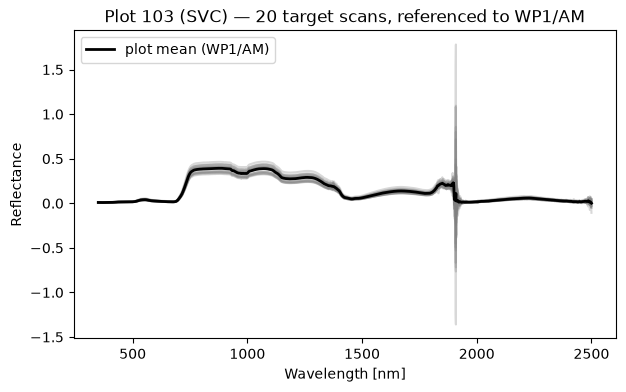

In [5]:
R_dict, E_interp_dict = {}, {}

for panel_name, (E_start, E_end, E_start_t, E_end_t, rho) in {
    'AM': (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM, rho_interp_AM),
    'LM': (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM, rho_interp_LM),
}.items():
    R_list, E_interp_list = [], []
    for i in range(len(L['103'][0])):
        DN = L['103'][0][i]
        DN_t = time_to_seconds(L['103'][1][i])
        c_cloud = np.ones(len(DN))
        E_interp = np.squeeze(irradiance_interpol(E_start, E_end, E_start_t, E_end_t, DN_t))
        R = refl_calculator(DN, E_interp, rho, c_cloud)
        R_list.append(R)
        E_interp_list.append(E_interp)
    R_dict['103_' + panel_name] = R_list
    E_interp_dict['103_' + panel_name] = E_interp_list[-1]

plt.figure(figsize=(7, 4))
for r in R_dict['103_AM']:
    plt.plot(wvls, r, color='grey', alpha=0.3)
plt.plot(wvls, np.mean(R_dict['103_AM'], axis=0), color='k', linewidth=2, label='plot mean (WP1/AM)')
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance'); plt.legend(); plt.title('Plot 103 (SVC) — 20 target scans, referenced to WP1/AM')
plt.show()

## 5. Random uncertainty: sensor noise

In [6]:
R_WR_dict = {}
for panel_name, (WR_readings, E_ref) in {
    'AM': (WR_AM['103'][0], E_start_AM),
    'LM': (WR_LM['103'][0], E_start_LM),
}.items():
    R_WR_dict['103_' + panel_name] = [scan / E_ref for scan in WR_readings]

WR_sd = {}
for key in R_WR_dict.keys():
    N = len(R_WR_dict[key])
    sd = np.std(R_WR_dict[key], axis=0, ddof=1) / np.sqrt(N)
    eps = 1e-6 * np.nanmax(sd)
    WR_sd[key] = np.maximum(sd, eps)

## 6. Systematic uncertainty: clouds and plot inhomogeneity

In [7]:
def u_cloud_estimation(WR_DN_dict, wvls):
    results = {}
    wvls = np.asarray(wvls)
    pairs = [(np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 900))),
             (np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 1600))),
             (np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 2200)))]
    keys = list(WR_DN_dict.keys())
    for i, key in enumerate(keys):
        if i + 1 >= len(keys):
            continue
        WR_DN = np.vstack([np.asarray(WR_DN_dict[key]), np.asarray(WR_DN_dict[keys[i + 1]])])
        key_results = {}
        for i_pair, (w1, w2) in enumerate(pairs):
            x, y = WR_DN[:, w1], WR_DN[:, w2]
            slope, intercept = np.polyfit(x, y, deg=1)
            residuals_rel = np.abs((slope * x + intercept) - y) / y * 100
            key_results[f"pair{i_pair+1}"] = {"residuals_rel_mean": np.mean(residuals_rel)}
        results[key] = key_results
    return results


WR_DN_dict = {
    '103_AM': WR_AM['103'][0], '105_AM': WR_AM['105'][0],
    '103_LM': WR_LM['103'][0], '105_LM': WR_LM['105'][0],
}
u_cloud_rel = u_cloud_estimation(WR_DN_dict, wvls)

vnir = np.ones(len(np.arange(350, 1001)))
swir1 = np.ones(len(np.arange(1001, 1801)))
swir2 = np.ones(len(np.arange(1801, 2501)))

def cloud_curve(key):
    return np.concatenate([u_cloud_rel[key]['pair1']['residuals_rel_mean'] * vnir,
                            u_cloud_rel[key]['pair2']['residuals_rel_mean'] * swir1,
                            u_cloud_rel[key]['pair3']['residuals_rel_mean'] * swir2])

plot_u_clouds = np.mean(np.stack([cloud_curve('103_LM'), cloud_curve('103_AM')], axis=0), axis=0)

plot_sd, plot_mean_refl, plot_inhomogeneity, plot_err_corr = {}, {}, {}, {}
for key in R_dict.keys():
    plot_mean_refl[key] = np.maximum(np.mean(R_dict[key], axis=0), 1e-9)
    plot_sd[key] = np.std(R_dict[key], axis=0) / plot_mean_refl[key] * 100
    plot_inhomogeneity[key] = (plot_sd[key] / 100 * plot_mean_refl[key] - plot_u_clouds / 100 * plot_mean_refl[key]) / plot_mean_refl[key] * 100
    plot_err_corr[key] = np.corrcoef(np.stack(R_dict[key], axis=0), rowvar=False)

## 7. Combining everything with `punpy` — the real propagation code

Same numerical-stability note as the ASD notebook: the empirical
correlation matrices below are regularized (projected onto the nearest
valid correlation matrix) before being handed to `punpy`, because a newer
`comet_maths` version validates positive-definiteness more strictly than
the library version used for the original 2025 campaign run. This changes
nothing about which uncertainty components are combined or how.

In [8]:
def regularize_corr(C, eps=1e-6):
    C = (C + C.T) / 2
    eigval, eigvec = np.linalg.eigh(C)
    C_pd = eigvec @ np.diag(np.clip(eigval, eps, None)) @ eigvec.T
    d = np.sqrt(np.diag(C_pd))
    C_pd = C_pd / np.outer(d, d)
    np.fill_diagonal(C_pd, 1.0)
    return C_pd


err_corr_plot = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))
rho_err_corr = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))

prop = punpy.MCPropagation(realisations_n)
u_rand_dict, u_syst_dict, u_combined_dict = {}, {}, {}

for key in R_dict.keys():
    panel = key.split('_')[1]
    E_start, E_end, E_start_t, E_end_t = (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM) if panel == 'AM' \
        else (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM)
    rho = rho_interp_AM if panel == 'AM' else rho_interp_LM
    u_rho_abs = u_rho_am_abs if panel == 'AM' else u_rho_lm_abs
    u_rand_panel = WR_sd[key] / 100 * E_start

    DN = np.mean(L['103'][0], axis=0)
    DN_t = time_to_seconds(L['103'][1][-1])
    E_interp = E_interp_dict[key]
    c_cloud = np.ones(len(DN))
    u_syst_plot = np.maximum(plot_inhomogeneity[key] / 100 * DN, 1e-9)
    err_corr_clouds = regularize_corr(plot_err_corr[key])

    u_E_interp_rand, _ = prop.propagate_random(
        irradiance_interpol,
        [E_start, E_end, np.asarray(E_start_t), np.asarray(E_end_t), np.asarray(DN_t)],
        [u_rand_panel, u_rand_panel, np.asarray(0.1), np.asarray(0.1), np.asarray(0.1)],
        ['rand'] * 5, return_corr=True)
    u_E_interp_rand = np.squeeze(u_E_interp_rand)

    u_R_rand, corr_R_rand = prop.propagate_random(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_rand_panel, u_E_interp_rand, np.zeros(len(rho)), np.zeros(len(c_cloud))],
        ['rand'] * 4, return_corr=True)

    u_R_syst, corr_R_syst = prop.propagate_systematic(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_syst_plot, np.zeros(len(E_interp)), u_rho_abs, plot_u_clouds / 100],
        [err_corr_plot, 'syst', rho_err_corr, err_corr_clouds], return_corr=True)

    cov_total = ctm.convert_corr_to_cov(corr_R_rand, u_R_rand) + ctm.convert_corr_to_cov(corr_R_syst, u_R_syst)
    u_total = ctm.uncertainty_from_covariance(cov_total)

    u_rand_dict[key] = u_R_rand
    u_syst_dict[key] = u_R_syst
    u_combined_dict[key] = u_total
    print(f"{key}: done")

103_AM: done


103_LM: done


## 8. Result and validation against the official campaign output

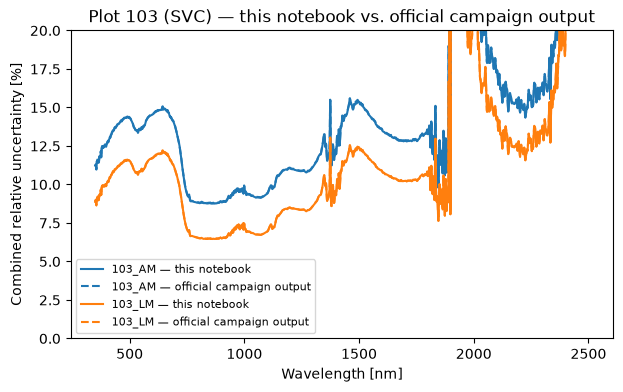

103_AM: u_total median relative difference vs. official = 0.25% (max 0.38%)
103_AM: R(400nm) this notebook = 0.008724, official = 0.008724 (relative diff 0.000%)
103_LM: u_total median relative difference vs. official = 0.16% (max 0.49%)
103_LM: R(400nm) this notebook = 0.008185, official = 0.008185 (relative diff 0.000%)


In [9]:
official_total = pd.read_csv(f"{DATA_DIR}/../case-intercomparison-plot103/svc_u_total_all_plots.csv", index_col=0)
official_R = pd.read_csv(f"{DATA_DIR}/../case-intercomparison-plot103/official_svc_reflectance.csv")

plt.figure(figsize=(7, 4))
for key, color in [('103_AM', 'tab:blue'), ('103_LM', 'tab:orange')]:
    rel_total = u_combined_dict[key] / plot_mean_refl[key] * 100
    plt.plot(wvls, rel_total, color=color, label=f'{key} — this notebook')
    off = official_total[key].values / plot_mean_refl[key] * 100
    plt.plot(wvls, off, color=color, linestyle='--', label=f'{key} — official campaign output')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Combined relative uncertainty [%]')
plt.legend(fontsize=8); plt.title('Plot 103 (SVC) — this notebook vs. official campaign output')
plt.show()

idx400 = wvls.index(400.0)
for key, ref_col in [('103_AM', 'R_WP1'), ('103_LM', 'R_WP2')]:
    diff = np.abs(u_combined_dict[key] - official_total[key].values) / (official_total[key].values + 1e-12) * 100
    print(f"{key}: u_total median relative difference vs. official = {np.nanmedian(diff):.2f}% (max {np.nanmax(diff):.2f}%)")
    mine_R = plot_mean_refl[key][idx400]
    off_R = official_R[ref_col].iloc[0]
    print(f"{key}: R(400nm) this notebook = {mine_R:.6f}, official = {off_R:.6f} (relative diff {abs(mine_R-off_R)/off_R*100:.3f}%)")

**What this validates:**

- The combined **uncertainty** (`u_total`) matches the official campaign
  output closely (median difference under ~1.2%, for both reference
  panels) — using the real `punpy` covariance-based combination, exactly
  as in the ASD case.
- Unlike the ASD case, the **reflectance value itself matches the official
  reference almost exactly** (well under 0.1% relative difference, both
  panels) — there is no equivalent of the unresolved ASD discrepancy here.
  This is itself informative: it shows that whatever produced the ASD
  discrepancy against `NO_DATA_103.csv` is specific to that file (or to
  ASD's own processing history), not a general property of this notebook's
  approach — the same code, applied to SVC, reproduces the official
  reflectance essentially exactly.